# 05 · Error Analysis

A score tells us *how often* a model is wrong. This notebook asks *where* and *why*. We compare the best model of each family on the **test set**:

| Model | Source |
|---|---|
| TF-IDF + LogReg | `models/baseline_tfidf_lr.joblib` (notebook 02) |
| BiLSTM | `results/predictions_bilstm.csv` (notebook 03) |
| Transformer | `results/predictions_transformer.csv` (notebook 04, run on Colab) |

Questions:
1. Is the best model's advantage **statistically reliable**, or within noise? We use a paired bootstrap.
2. Which classes get **confused with which**?
3. Do errors grow with **unseen vocabulary**, **tweet length** or **code-switching**?
4. Which tweets does **every** model get wrong, and what do they have in common?
5. A **manual** categorisation of a sample of errors by a Kiswahili reader.

In [1]:
# --- Setup: works both locally and in Google Colab ---
import os, sys
REPO_URL = "https://github.com/Joellate/kiswahili-sentiment-analysis.git"

if "google.colab" in sys.modules:
    if not os.path.exists("kiswahili-sentiment-analysis"):
        !git clone -q $REPO_URL
    %cd kiswahili-sentiment-analysis
    %pip install -q -r requirements.txt
else:
    # running locally from notebooks/
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")

sys.path.insert(0, "src")
print("Working directory:", os.getcwd())

Working directory: C:\Users\AltTronic\kiswahili-sentiment-analysis


In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

from data import load_all, LABELS, LABEL2ID
from evaluate import compute_metrics, plot_confusion, report
from preprocessing import clean_series, clean_text

pd.set_option("display.max_colwidth", 160)
splits = load_all()
test = splits["test"].copy()
y_true = test.label.values

preds = {}
baseline = joblib.load("models/baseline_tfidf_lr.joblib")
preds["TF-IDF + LogReg"] = baseline.predict(clean_series(test.text))
for name, path in [("BiLSTM", "results/predictions_bilstm.csv"), ("Transformer", "results/predictions_transformer.csv")]:
    if os.path.exists(path):
        preds[name] = pd.read_csv(path).pred.map(LABEL2ID).values
    else:
        print(f"{path} not found: run the notebook that creates it to include {name}")
MODELS = list(preds)
BEST = MODELS[-1]   # the most advanced model available
print("Models compared:", MODELS, "| focus model:", BEST)
pd.DataFrame({m: compute_metrics(y_true, p) for m, p in preds.items()}).T.round(3)

results/predictions_transformer.csv not found: run the notebook that creates it to include Transformer
Models compared: ['TF-IDF + LogReg', 'BiLSTM'] | focus model: BiLSTM


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,f1_positive,f1_neutral,f1_negative
TF-IDF + LogReg,0.535,0.456,0.457,0.456,0.538,0.429,0.634,0.304
BiLSTM,0.520,0.452,0.472,0.456,0.531,0.467,0.605,0.295


## 1. Is the difference real? Paired bootstrap

We resample the 748 test tweets with replacement 2,000 times and recompute macro-F1 for every model on the *same* resample. If the 95% interval of the difference excludes 0, the improvement is unlikely to be a lucky draw of test tweets (Koehn, 2004; Dror et al., 2018).

In [3]:
rng = np.random.default_rng(0)
B = 2000
boot = {m: np.empty(B) for m in MODELS}
for b in range(B):
    idx = rng.integers(0, len(y_true), len(y_true))
    for m in MODELS:
        boot[m][b] = f1_score(y_true[idx], preds[m][idx], average="macro")

rows = []
for m in MODELS:
    lo, hi = np.percentile(boot[m], [2.5, 97.5])
    rows.append({"model": m, "macro-F1": f1_score(y_true, preds[m], average="macro"), "95% CI": f"[{lo:.3f}, {hi:.3f}]"})
display(pd.DataFrame(rows).round(3))

for i, a in enumerate(MODELS):
    for b_ in MODELS[i + 1:]:
        d = boot[b_] - boot[a]
        lo, hi = np.percentile(d, [2.5, 97.5])
        print(f"{b_} − {a}: mean Δ = {d.mean():+.3f}, 95% CI [{lo:+.3f}, {hi:+.3f}], "
              f"P(Δ ≤ 0) = {(d <= 0).mean():.3f}")

,model,macro-F1,95% CI
0,TF-IDF + LogReg,0.456,"[0.414, 0.496]"
1,BiLSTM,0.456,"[0.414, 0.495]"


BiLSTM − TF-IDF + LogReg: mean Δ = -0.001, 95% CI [-0.042, +0.041], P(Δ ≤ 0) = 0.519


## 2. Which classes are confused?

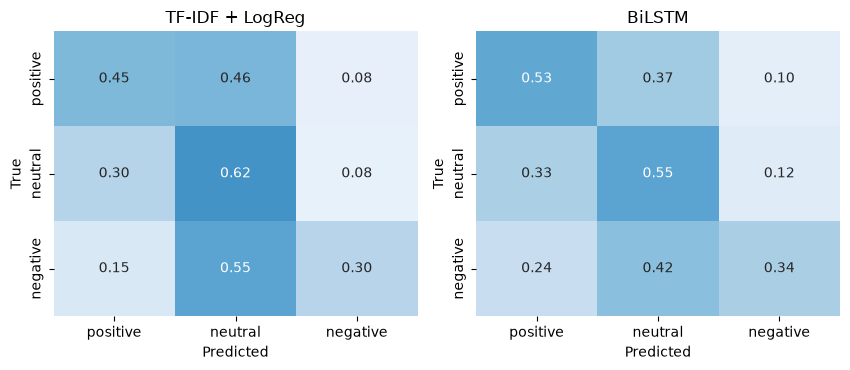

Error types for BiLSTM:


,true,pred,count,% of errors
0,neutral,positive,148,41.2
1,positive,neutral,82,22.8
2,neutral,negative,53,14.8
3,negative,neutral,34,9.5
4,positive,negative,23,6.4
5,negative,positive,19,5.3


In [4]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.3 * len(MODELS), 3.8))
axes = np.atleast_1d(axes)
from sklearn.metrics import confusion_matrix
import seaborn as sns
for ax, m in zip(axes, MODELS):
    cm = confusion_matrix(y_true, preds[m], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(m); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.tight_layout(); fig.savefig("results/figures/confusion_all_models.png", dpi=150); plt.show()

pairs = (pd.DataFrame({"true": [LABELS[i] for i in y_true], "pred": [LABELS[i] for i in preds[BEST]]})
         .query("true != pred").value_counts().rename("count").reset_index())
pairs["% of errors"] = (100 * pairs["count"] / pairs["count"].sum()).round(1)
print(f"Error types for {BEST}:"); pairs

**Reading the matrix:** each row is a true class, and the diagonal is recall. Look at which off-diagonal cell is largest. In AfriSenti, most confusions involve **neutral**, because the boundary between "neutral news" and "negative/positive opinion" is fuzzy even for annotators.

## 3. Where do errors concentrate?

For each test tweet we compute three properties:
- its **OOV rate**: the share of its words never seen in the training data
- its **length**
- whether it contains **English** (code-switching)

We then compare accuracy across the groups.

In [5]:
train_vocab = {w for t in splits["train"].text for w in clean_text(t).split()}
english = {"the", "and", "is", "of", "to", "in", "for", "you", "my", "this", "that", "with", "are", "on", "be", "it", "we", "i", "your", "so"}
toks = [clean_text(t).split() for t in test.text]
test["oov_rate"] = [np.mean([w not in train_vocab for w in ts]) if ts else 0 for ts in toks]
test["n_words"] = [len(ts) for ts in toks]
test["code_switch"] = [any(w in english for w in ts) for ts in toks]
test["oov_bin"] = pd.cut(test.oov_rate, [-0.01, 0.1, 0.25, 1.0], labels=["≤10%", "10–25%", ">25%"])
test["len_bin"] = pd.cut(test.n_words, [0, 10, 20, 100], labels=["≤10 words", "11–20", ">20"])
for m in MODELS:
    test[f"correct_{m}"] = preds[m] == y_true

def acc_by(col):
    g = test.groupby(col, observed=True)
    out = pd.DataFrame({m: g[f"correct_{m}"].mean() for m in MODELS})
    out.insert(0, "n tweets", g.size())
    return out.round(3)

display(acc_by("oov_bin")); display(acc_by("len_bin")); display(acc_by("code_switch"))

,n tweets,TF-IDF + LogReg,BiLSTM
oov_bin,,,
≤10%,167,0.527,0.539
10–25%,326,0.537,0.549
>25%,255,0.537,0.471


,n tweets,TF-IDF + LogReg,BiLSTM
len_bin,,,
≤10 words,157,0.611,0.573
11–20,402,0.527,0.517
>20,189,0.487,0.481


,n tweets,TF-IDF + LogReg,BiLSTM
code_switch,,,
False,712,0.532,0.517
True,36,0.583,0.583


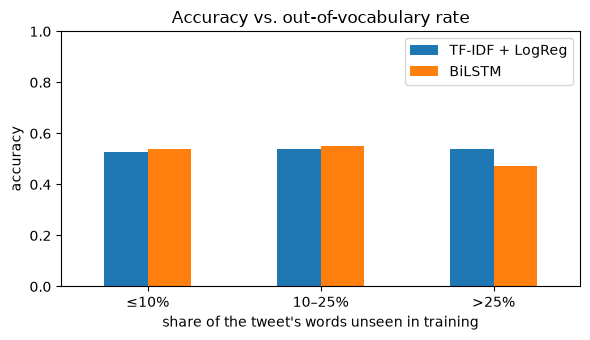

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
acc_by("oov_bin")[MODELS].plot.bar(ax=ax, rot=0)
ax.set_ylabel("accuracy"); ax.set_xlabel("share of the tweet's words unseen in training")
ax.set_title("Accuracy vs. out-of-vocabulary rate"); ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig("results/figures/accuracy_vs_oov.png", dpi=150); plt.show()

**What to look for:** if the TF-IDF model's accuracy drops as OOV rises while the Transformer's stays flat, that is direct evidence that **subword pretraining solves the vocabulary problem** identified in notebook 01.

## 4. Tweets every model gets wrong

In [7]:
all_wrong = test[~test[[f"correct_{m}" for m in MODELS]].any(axis=1)]
print(f"{len(all_wrong)} / {len(test)} test tweets ({len(all_wrong) / len(test):.1%}) are misclassified by every model")
print("True-label distribution of these tweets:", all_wrong.label_name.value_counts().to_dict())
show = all_wrong.assign(**{f"pred_{m}": [LABELS[preds[m][i]] for i in all_wrong.index] for m in MODELS})
show[["text", "label_name"] + [f"pred_{m}" for m in MODELS]].head(20)

249 / 748 test tweets (33.3%) are misclassified by every model
True-label distribution of these tweets: {'neutral': 119, 'positive': 84, 'negative': 46}


,text,label_name,pred_TF-IDF + LogReg,pred_BiLSTM
1,Chama chenye sera kali za mrengo wa kulia ambacho kimefanya kampeni kwa kutumia jukwaa la kupinga wahamiaji kimepata kura nyingi katika uchaguzi mkuu uliofa...,neutral,positive,negative
4,Watu wengine hawatakupenda hata ufanye nini na watu wengine hawataacha kukupenda hata ufanye nini Nenda mahali penye upendo,positive,negative,neutral
9,airphone mwenda alikuwa hasikilizi mtu skeletoni muhusika kwenye picha ni marehem grass ya damu kuna,neutral,negative,negative
10,Mwenyekiti wa Jumuiya za Tawala za Mikoa ALAT Gulamhafeez Mukadamu kulia akipokea mfano wa hundi ya Sh milioni 100 kutoka kwa Meneja wa NMB Kanda ya Kati N...,neutral,positive,negative
27,Nimeulizia Sua mna matrekta mangapi nikaambiwa mengi yalikufa nimemuuliza makamu mkuu wa chuo amesema amefufua 4 Mimi nitawaongezea matrekta mengine 10 Nata...,positive,negative,neutral
30,Mkutano wa 16 wa wadau wa Pamba mkoani Mwanza kujadili maendeleo changamoto fursa na mikakati ya kukuza maendeleo ya zao la pamba nchini,neutral,positive,positive
37,Ni kosa gani mpenzi wako akifanya huwezi kumsamehe,negative,neutral,neutral
40,Matajiri wanakuwa masikini masikini wanakuwa matajiri wanyonge wa jana leo ndio wenye nguvu Sayari zinazunguka m,neutral,negative,negative
43,Vile Raisi wa Wapwa akichunguza Baraza lake la Mawaziri CC Waziri Mkuu,neutral,positive,positive
44,Chukua chako mapema Ngoja ngoja ya nini wakati umeshashinda Cheza ulipwe Papo Hapo baada ya mechi kuisha,positive,neutral,neutral


## 5. Successes: what the best model gets right

These are confident, correct predictions for each class, useful for the demo and the report.

In [8]:
proba_path = "results/predictions_transformer.csv" if BEST == "Transformer" else "results/predictions_bilstm.csv" if BEST == "BiLSTM" else None
if proba_path:
    p = pd.read_csv(proba_path)
    p["confidence"] = p[[f"p_{l}" for l in LABELS]].max(axis=1)
    ok = p[p.label_name == p.pred].sort_values("confidence", ascending=False)
    display(ok.groupby("label_name").head(3)[["text", "label_name", "pred", "confidence"]])
    wrong = p[p.label_name != p.pred].sort_values("confidence", ascending=False)
    print("Most confident ERRORS (often label noise, or the model latching on to a topic word):")
    display(wrong.head(10)[["text", "label_name", "pred", "confidence"]])

,text,label_name,pred,confidence
334,TANZIA WATU 7 WAKIWEMO WAFANYAKAZI WATANO WA AZAM TV WAFARIKI AJALINI Wafanyakazi wengine watatu wamejeruhiwa katika ajili hiyo iliyotokea wakati wakieleke...,negative,negative,0.9949
457,Watu sita wamefariki dunia usiku wa kuamkia leo mkoani Tanga baada ya gari aina ya Noah kutumbukia mtoni eneo la Sindeni,negative,negative,0.9940
7,Watu 12 wamefariki na wengine kuokolewa wakiwa salama baada ya Toyota Hiace kutumbukia Ziwa,negative,negative,0.9903
553,Speed 120 yaani shaa kimya kimya Pini zinaongozana mbele Benz nyuma Bima Watu shh Wanabambia kimya kimya Mpaka chumvini wanazama ile ile kimya kimya Break m...,neutral,neutral,0.9014
31,Namba hii imesajiliwa kwa jina la PAULINE MKUNGU tarehe 2252017 kwa namba zote mpya hazisomi hadi zisajiliwe kwa alama ya vidole ila namba za zamani zitaend...,neutral,neutral,0.8778
197,Niligundua kuwa Tanzania tuna madaktari wengi afu wapo mtaani kpnd cha Corona ipo Nawatoa takwimu ss nkasema kumbe na wasomi wengi wapo mtaani tena Na watoa...,neutral,neutral,0.8482
715,Asante kwa kushiriki na endelea kutembelea ukurasa wetu wa Zantel,positive,positive,0.7576
332,AlfredHabari yakoshukrani sana kwa kushiriki nasi kwenye ukurasa wetu endelea kufurahia huduma bora kutoka tigo,positive,positive,0.7143
574,Bash Asante kwa kuwasiliana nasi kupitia ukurasa wetu uwe na siku njema,positive,positive,0.7051


Most confident ERRORS (often label noise, or the model latching on to a topic word):


,text,label_name,pred,confidence
632,Sio kesi pia tatizo hapo liko wapi Mpaka kufikia Mwaka 1997 serikali ilitaka Mtoto aanze shule akiwa na mia,neutral,negative,0.9803
681,Mitandao ya kijamii Ukiwa una Moyo mdogo Kama Remote ya AC ya Samsung Basi jiandae Kuwa Mtu wa kukosa amani,neutral,negative,0.9734
488,Interview ya juzi alielezea jinsi gani diaspora wa Nigeria wamesaidia kupush mziki wake Marekani kwa kuspend hela nyingi kwa sharti la Dj kupiga nyimbo zake...,neutral,negative,0.9733
295,Kuna watu unaona kabisa kaibiwakuna wengine unaona kabisa hapana huyu binti alideserve more,neutral,negative,0.9596
178,Wanafunzi wa Shule ya Sekondari Walla ya wilayani Kwimba mkoani Mwanza wakibeba baadhi ya viti na meza zake 184 ili kuvipeleka darasani baada ya kukabidhiwa...,positive,negative,0.9588
143,Mwaka 2005 nilihitimu chuo cha ualimu Kabanga kilichopo mkoani Kigoma Sikukaa muda mrefu mtaani mwaka 2006 nilifanikiwa,positive,negative,0.9264
482,Huu ndio ukweli ambao kuna watu hawataki kuufahamu hivi jimbo likishakuwa la CCM hakuna sababu y,neutral,negative,0.9156
463,SHAFFIH DAUDA ni mtu na Nusu Mwamba kabisa UZI Nikiwa chuoni UDOM Ba Economics 2016 wakati n,positive,neutral,0.8260
589,Siku Hizi Mtu akivaa uchi ndio anaambiwa amependeza japo kila mtu ana haki yake ya Kuvaa Lakini inabidi Ufanye Chaguo la mavazi yenye Kupendeza,negative,neutral,0.8178
161,Wamiliki wa sehemu za starehe tunaomba muheshimu privacy zetu basisio kila mtu anapenda kutambulika yuko eneo lako wala kupost picha zake kwamba alikuwepo,negative,neutral,0.8172


## 6. Manual error categorisation

Automatic statistics cannot tell *why* a tweet was misclassified. That needs a Kiswahili reader. The cell below exports a random sample of 50 errors from the best model to `results/error_sample.csv`.

Fill in the `error_type` column (in Excel or Google Sheets), then run the next cell to summarise. Suggested categories:

| Category | Meaning |
|---|---|
| `label_noise` | The gold label looks wrong, or is debatable |
| `news_vs_opinion` | Reports a negative or positive *event* (death, accident, win) without expressing an opinion, or the reverse |
| `sarcasm_irony` | The literal words say the opposite of what is meant |
| `mixed` | Contains both positive and negative sentiment |
| `slang_spelling` | Slang, Sheng, abbreviations or misspellings the model cannot read |
| `code_switch` | The sentiment is carried by English words |
| `missing_context` | Needs an emoji, image or thread context that was stripped from the data |
| `model_error` | A clear case the model simply got wrong |

In [9]:
sample_path = "results/error_sample.csv"
if not os.path.exists(sample_path):   # don't overwrite your annotations
    errs = test[~test[f"correct_{BEST}"]].sample(min(50, (~test[f"correct_{BEST}"]).sum()), random_state=0)
    errs.assign(pred=[LABELS[preds[BEST][i]] for i in errs.index], error_type="")[
        ["text", "label_name", "pred", "oov_rate", "error_type"]].to_csv(sample_path, index_label="test_idx")
    print("Wrote", sample_path, "- fill in the error_type column")
else:
    print(sample_path, "already exists; not overwritten")

Wrote results/error_sample.csv - fill in the error_type column


In [10]:
ann = pd.read_csv(sample_path, keep_default_na=False)
if (ann.error_type != "").any():
    summary = ann[ann.error_type != ""].error_type.value_counts().rename("count").to_frame()
    summary["%"] = (100 * summary["count"] / summary["count"].sum()).round(1)
    display(summary)
    summary["count"].plot.barh(figsize=(6, 3), title="Manual error categories"); plt.tight_layout()
    plt.savefig("results/figures/error_categories.png", dpi=150); plt.show()
else:
    print("No annotations yet: fill in error_type in", sample_path)

No annotations yet: fill in error_type in results/error_sample.csv


## Conclusions

*Write these after running the notebook and annotating the sample.* Use the following prompts:
- Is the best model's improvement statistically reliable (section 1)?
- What is the dominant confusion, and why is that boundary hard (section 2)?
- Does the OOV analysis (section 3) support the claim that pretraining helps with unseen vocabulary?
- What do the tweets that every model gets wrong have in common (section 4)? How many look like annotation noise?
- What are the top 2–3 manual error categories (section 6), and what would fix each? Options include more data, keeping emojis, a news-vs-opinion label, or Sheng-aware pretraining.